# We import relevant libraries

In [1]:
import  numpy as np
import  matplotlib.pyplot as plt
import  seaborn as sns
import  numpy.random
import  pandas as pd
from    collections import Counter

# We import the provided data

In [4]:
with open("war_and_peace.txt", "r", encoding="utf-8") as f:
    war_and_peace = f.read()

war_and_peace     = war_and_peace.replace("\n", "").lower()

symbols           = open("symbols.txt", "r").read()
symbols           = symbols.replace("\n", "")

encrypted_message = open("message.txt", "r").read()

# Question a

### We define relevant functions

In [5]:
def transition_mat(text, symbols):
    """
    Compute the transition probability matrix for a sequence.

    Parameters
    ----------
    text : sequence of hashable
        Sequence of observed symbols (e.g., characters, tokens, states).
    symbols : list of hashable
        Ordered list of unique symbols defining the states of the Markov chain.

    Returns
    -------
    transition_matrix : numpy.ndarray, shape (n_symbols, n_symbols)
        Matrix T where T[i, j] = P(symbol_i at t | symbol_j at t-1).
    """

    matrix = np.zeros(shape=(len(symbols),len(symbols)))

    for i in range(len(text)):
        if text[i-1] in symbols and text[i] in symbols:
            beta, alpha = symbols.index(text[i-1]), symbols.index(text[i])
            matrix[alpha][beta] += 1
        else:
            continue

    transition_matrix = np.zeros((len(symbols),len(symbols)))
    for i in range(len(symbols)):
        # We divide every coefficient of each column by the sum of 
        # the coefficients of the column to ensure that each column sum to 1
        transition_matrix[i,:] = matrix[i,:]/(np.sum(matrix,axis=1)[i])

    return transition_matrix

def Stationary_Distributions(text):
    """
    Compute the empirical stationary distribution of symbols in a sequence.

    Parameters
    ----------
    text : sequence of hashable
        Sequence of observed symbols.

    Returns
    -------
    stationary_distribution : numpy.ndarray, shape (1, n_symbols)
        Row vector of frequencies normalized to sum to 1 for each symbol.
    """

    stationary_distribution = np.zeros((1,len(symbols)))
    
    for i in range(len(text)):
        if text[i] in symbols:
            index = symbols.index(text[i])
            stationary_distribution[0][index] += 1
        else:
            continue

    stationary_stistribution_final = np.zeros((1,len(symbols)))
    for i in range(len(symbols)):
        # We divide every coefficient of our matrix by the sum of 
        # the coefficients of the matrix to ensure that the coefficients sum to 1
        stationary_stistribution_final[0][i] = stationary_distribution[0][i]/(np.sum(stationary_distribution[0]))

    return stationary_stistribution_final

### We plot our transition matrix as a heatmap 


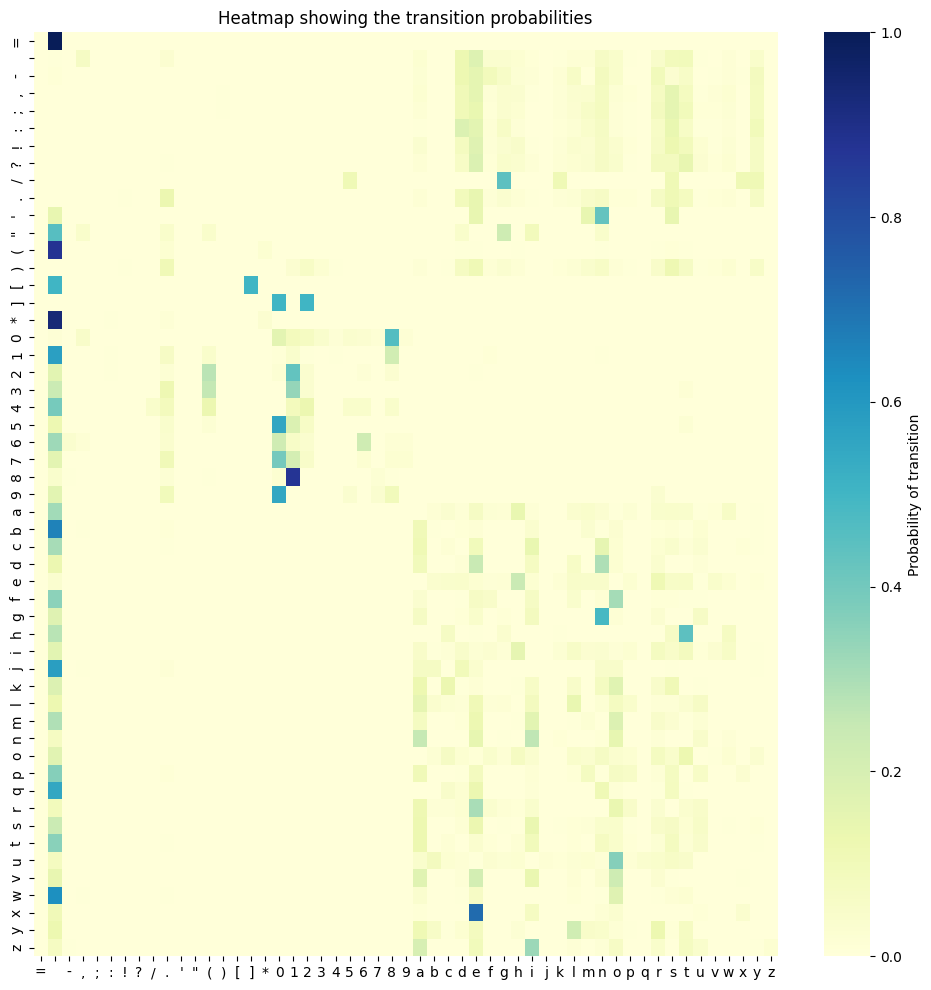

In [6]:
plt.figure(figsize=(12, 12))  # Taille de la figure
sns.heatmap(transition_mat(war_and_peace,symbols), cmap="YlGnBu", 
            cbar=True, cbar_kws={'label': 'Probability of transition'}, 
            xticklabels=symbols, yticklabels=symbols)
plt.title("Heatmap showing the transition probabilities")
plt.show()

### We plot our stationary distribution matrix as a heatmap

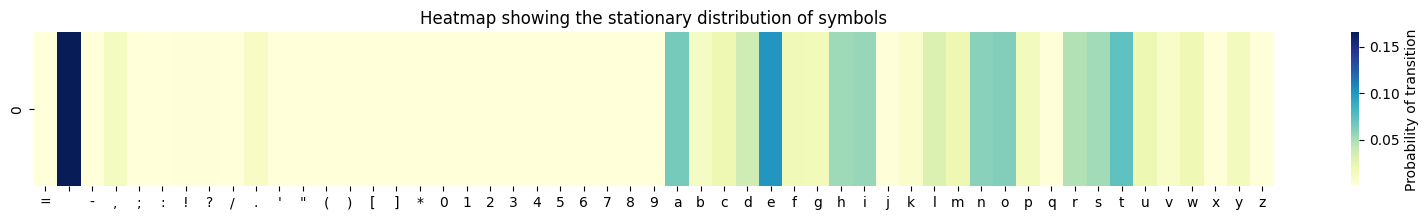

In [7]:
plt.figure(figsize=(20, 2))
sns.heatmap(Stationary_Distributions(war_and_peace), cmap="YlGnBu", 
            cbar=True, cbar_kws={'label': 'Probability of transition'}, 
            xticklabels=symbols)
plt.title("Heatmap showing the stationary distribution of symbols")
plt.show()

# Question d

### We define relevant functions

In [8]:
def decrypt_message(encrypted_message, sigma):
    """
    Decrypt an encrypted message using a substitution cipher defined by sigma.

    Parameters
    ----------
    encrypted_message : str or list of hashable
        Sequence of encrypted symbols to be decrypted.
    sigma : list of hashable
        Permutation of the symbol alphabet where sigma[i] is the encrypted form of symbols[i].

    Returns
    -------
    decrypted_message : str
        The message obtained by substituting each encrypted symbol with its corresponding plaintext symbol.
    """
    
    decripted_message = ''
    
    for letter in encrypted_message :
        decripted_message += symbols[sigma.index(letter)]
    
    return decripted_message

def loglikelihood(encrypted_message, stationary_distribution, sigma, transition_matrix):
    """
    Compute the log-likelihood of a decrypted message under a given Markov model.

    Parameters
    ----------
    encrypted_message : str or list of hashable
        Sequence of encrypted symbols whose likelihood is evaluated.
    stationary_distribution : array-like, shape (n_symbols,)
        Empirical stationary probabilities for each symbol.
    sigma : list of hashable
        Current decryption key mapping plaintext to cipher symbols.
    transition_matrix : ndarray, shape (n_symbols, n_symbols)
        Column-stochastic transition probability matrix of the underlying Markov chain.

    Returns
    -------
    log_likelihood : float
        Sum of the log probabilities of the initial symbol and each subsequent transition.
    """
    
    decripted_message = decrypt_message(encrypted_message, sigma)
    log_likelihood = np.log(stationary_distribution[symbols.index(decripted_message[0])]+10**(-4))
    for k in range (0, len(encrypted_message)):
        alpha = symbols.index(decripted_message[k])
        beta = symbols.index(decripted_message[k-1])
        log_likelihood += np.log(transition_matrix[alpha][beta]+10**(-4))
    return log_likelihood

def mcmc_step(sigma, p_old, transition_matrix, stationary_distribution):
    """
    Perform one Metropolis–Hastings MCMC step by proposing a swap in sigma.

    Parameters
    ----------
    sigma : list of hashable
        Current permutation of the symbol alphabet.
    p_old : float
        Log-likelihood of the current sigma.
    transition_matrix : ndarray, shape (n_symbols, n_symbols)
        Transition probabilities for the Markov model.
    stationary_distribution : array-like, shape (n_symbols,)
        Stationary distribution of the Markov model.

    Returns
    -------
    sigma_new : list of hashable
        Updated permutation (same as sigma if proposal is rejected).
    accepted : bool
        Whether the proposed swap was accepted.
    p_new : float
        Log-likelihood of sigma_new (or p_old if rejected).
    """  

    #Select two random symbols
    symbols_= sigma[:]
    proposal_1 = np.random.choice(symbols_)
    symbols_.remove(proposal_1)
    proposal_2 = np.random.choice(symbols_)

    #Get their respective indexes
    index1 = sigma.index(proposal_1)
    index2 = sigma.index(proposal_2)

    #Switch the indexes to create a new list of symbols, sigma_new
    sigma_new = sigma[:]
    sigma_new[index1], sigma_new[index2] = sigma_new[index2], sigma_new[index1]

    #Compute the new log likelihood
    p_new = loglikelihood(encrypted_message, stationary_distribution, list(sigma_new), transition_matrix)

    #Define the rejection kernel
    threshold = min(1,np.exp(p_new-p_old))
    
    #Accept or reject sigma_new
    if (p_new >= p_old) or (threshold >= np.random.uniform(0,1)):
        accepted=True
        return sigma_new, accepted, p_new
    else:
        accepted=False
        return sigma, accepted, p_old
    
def run_mcmc(N_iters, sigma_init, p_old, transition_matrix, stationary_distribution):
    """
    Run the MCMC algorithm for a given number of iterations and collect diagnostics.

    Parameters
    ----------
    N_iters : int
        Total number of MCMC iterations to perform.
    sigma_init : list of hashable
        Initial permutation of the symbol alphabet.
    p_old : float
        Log-likelihood of sigma_init.
    transition_matrix : ndarray, shape (n_symbols, n_symbols)
        Transition probabilities for the Markov model.
    stationary_distribution : array-like, shape (n_symbols,)
        Stationary distribution of the Markov model.

    Returns
    -------
    sigma_chain : ndarray, shape (N_iters+1, n_symbols)
        Sequence of sigma permutations over iterations.
    p_chain : ndarray, shape (N_iters+1,)
        Log-likelihood values corresponding to sigma_chain.
    acceptance_rate : float
        Fraction of proposed moves that were accepted.
    report_df : pandas.DataFrame
        Summary of iterations, decrypted message snippets, and log-likelihoods every 100 steps.
    """
    #We instanciate our variables
    sigma_chain = [sigma_init]
    p_old_chain=[p_old]
    N_accepted = 0
    data_for_report={"Number of iterations" : [], "Decrypted message" : [], "Loglikelihood" : []}

    #We run the algorithm
    for _ in range(N_iters):
        sigma, accepted, p_old = mcmc_step(sigma_chain[-1], p_old_chain[-1], transition_matrix, stationary_distribution)
        sigma_chain.append(sigma)
        p_old_chain.append(p_old)
        N_accepted += accepted

        #We capture our data every 100 iteration, for the report
        if _ % 100 == 0:
            data_for_report["Number of iterations"].append(_)
            data_for_report["Decrypted message"].append(decrypt_message(encrypted_message, list(sigma))[:60])
            data_for_report["Loglikelihood"].append(p_old)
        
    return np.stack(sigma_chain), np.stack(p_old_chain), N_accepted / N_iters, pd.DataFrame.from_dict(data_for_report)

def kth_largest_index(lst, k):
    """
    Return the index of the k-th largest unique element in a list.

    Parameters
    ----------
    lst : list of comparable
        List in which to find the k-th largest unique value.
    k : int
        Zero-based rank of the element (0 for largest, 1 for second largest, etc.).

    Returns
    -------
    index : int
        Position of the k-th largest unique element in the original list.

    Raises
    ------
    ValueError
        If k is out of range of the number of unique elements.
    """

    #Sort the list in descending order, keeping only unique values
    unique_sorted = sorted(set(lst), reverse=True)
    
    # Check if k is within the range of unique elements
    if k > len(unique_sorted) :
        raise ValueError("k is out of range for the number of unique elements in the list.")
    
    #Get the k-th largest element
    kth_largest_element = unique_sorted[k]
    
    #Find the index of the k-th largest element in the original list
    return list(lst).index(kth_largest_element)

def intelligent_initialization(sigma, stationary_distribution, encrypted_message):
    """
    Initialize sigma by matching the most frequent encrypted symbols to the most frequent stationary symbols.

    Parameters
    ----------
    sigma : list of hashable
        Initial permutation of the symbol alphabet.
    stationary_distribution : array-like, shape (n_symbols,)
        Stationary probabilities for each symbol.
    encrypted_message : str or list of hashable
        Sequence of encrypted symbols to analyze frequency.

    Returns
    -------
    sigma_new : list of hashable
        Permutation after assigning the k most frequent encrypted symbols to the k most frequent stationary symbols.
    """    
    sigma_new=sigma[:]

    for k in range (len(Counter(encrypted_message).most_common())) :
        
        #We extract the k most recurring symbol of our encripted message, and its index in our symbol list
        k_most_recurring_symbol_encrypted=Counter(encrypted_message).most_common()[k][0]
        index_k_most_recurring_symbol_encrypted=sigma.index(k_most_recurring_symbol_encrypted)
 
        #We extract the k most recurring symbol of our stationary distribution, and its index in our symbol list
        index_k_most_recurring_symbol_stationary=kth_largest_index(stationary_distribution, k)

        #We assign the most k most recurring symbol of our encripted message to the k most recurring symbol of our stationary distribution
        sigma_new[index_k_most_recurring_symbol_stationary], sigma_new[index_k_most_recurring_symbol_encrypted] = sigma_new[index_k_most_recurring_symbol_encrypted], sigma_new[index_k_most_recurring_symbol_stationary]

    return sigma_new


### We run the MCMC algorithm

In [9]:
N_samples               = 15000
transition_matrix       = transition_mat(war_and_peace, symbols)
stationary_distribution = Stationary_Distributions(war_and_peace)[0]
p_old_init              = loglikelihood(encrypted_message, stationary_distribution, 
                                        list(symbols), transition_matrix)
initial_sigma           =   intelligent_initialization(list(symbols), 
                                                       stationary_distribution, 
                                                       encrypted_message)

sigma_chain, p_old_chain, accepted, data_for_report = run_mcmc(N_samples, 
                                                               initial_sigma, 
                                                               p_old_init, 
                                                               transition_matrix, 
                                                               stationary_distribution)

print("Acceptance Rate:", accepted)
print("Decrypted Message:", decrypt_message(encrypted_message, list(sigma_chain[-1])))

C:\Users\benoi\AppData\Local\Temp\ipykernel_28664\3923084639.py:97: RuntimeWarning: overflow encountered in exp
  threshold = min(1,np.exp(p_new-p_old))


Acceptance Rate: 0.1636
Decrypted Message: in my younger and more vulnerable years my father gave me some advice that ixve been turning over in my mind ever since. (whenever you feel like criticizing any one,( he told me, (just remember that all the people in this world havenxt had the advantages that youxve had.( he didnxt say any more but wexve always been unusually communicative in a reserved way, and i understood that he meant a great deal more than that. in consequence ixm inclined to reserve all judgments, a habit that has opened up many curious natures to me and also made me the victim of not a few veteran bores. the abnormal mind is quick to detect and attach itself to this quality when it appears in a normal person, and so it came about that in college i was unjustly accused of being a politician, because i was privy to the secret griefs of wild, unknown men. most of the confidences were unsought--frequently i have feigned sleep, preoccupation, or a hostile levity when i reali

In [10]:
print("-- Decrypted message and log-lokelihood at each iteration-- ")
data_for_report

-- Decrypted message and log-lokelihood at each iteration-- 


,Number of iterations,Decrypted message,Loglikelihood
0,0,ofkw1k1h.f;esktf:kwhsekn.gfestpgek1etsikw1kyta...,-7723.464743
1,100,"ondg(d(-rnlesdtn,dg-sedmrfnest.fed(etsidg(dyt ...",-6344.670933
2,200,"onabuau-kniesatn,ab-searkfnestwfeauetslabuayt ...",-5762.560878
3,300,intbutu-knoeftanptb-fetrksnefawsetueafltbutya ...,-5565.342759
4,400,inthutu-knoeftanpth-fetrksnefawsetueaflthutya ...,-5317.615680
...,...,...,...
145,14500,in my younger and more vulnerable years my fat...,-3570.890580
146,14600,in my younger and more vulnerable years my fat...,-3570.890580
147,14700,in my younger and more vulnerable years my fat...,-3570.890580
148,14800,in my younger and more vulnerable years my fat...,-3570.291669
